# Lamas — Occupation Classification — Flat Pipeline (no hierarchy assumed)

End-to-end Colab-ready pipeline for predicting `SemelMishlachSofi`.
Unlike the earlier cascade pipeline, this plan **assumes no prior knowledge**
of the target codes' internal structure. The 62 codes are treated as 62
unrelated categorical labels. Hierarchy reappears only in Stage 7 as a
post-fit empirical observation we extract from the model's own behaviour.

## What's different from the cascade pipeline

| Removed | Reason | Replacement |
|---|---|---|
| LR cascade (4 models, one per ISCO digit) | requires hierarchy knowledge | flat 62-way LR |
| Stratification on `y_d1` | requires hierarchy knowledge | frequency-binned stratification (top-K + 'rare') |
| `acc@1`, `acc@2`, `acc@3` as primary metrics | requires hierarchy knowledge | top-1, top-3, macro-F1, AUC, PR-AUC, κ, Brier, log-loss, ECE |

## What's added vs. the cascade pipeline

- **k-NN classifier** — non-parametric retrieval, well suited to small data. Diversifies the ensemble.
- **Soft-vote ensemble** — probability-average of the parametric models.
- **Reliability diagram + ECE** — directly justifies a deployment confidence threshold.
- **One-vs-rest macro AUC and PR-AUC** — threshold-free discrimination metrics.
- **Cohen's κ** (unweighted and quadratic-weighted via integer-encoded codes) — chance-corrected accuracy.
- **Post-fit `classification_report` aggregated by the first character of the code** — readable 8-class drill-down derived from the 62-way predictions; no schema knowledge used.

## Sections

- A. Colab setup
- 0. Imports and Hebrew display
- 1. EDA (data quality)
- 2. Preprocessing (forward-fill, document construction, X-coded handling)
- 3. Train/test split with **frequency-binned stratification**
- 4. Feature builders (TF-IDF, tabular, optional sentence embeddings)
- 5. Models — Baseline / LR flat / LightGBM / **k-NN** / (optional) embeddings + LR / **Soft-vote ensemble**
- 6. Evaluation — extended metric block
- 7. Insights — PR curves, top-15 confusion, reliability, threshold sweep, post-fit hierarchy observation
- 8. Save artefacts


## Examiner-recommended corrections (vs. previous version)

Three changes from `modified_flat_lamas_pipeline.ipynb`, in order:

1. **Baseline filtering (M3).** The baseline accuracy now applies the same `~is_x` filter as the learned models. Without this fix the baseline was penalised on the 9 X-coded rows (~4.5% of train) that no model can match.
2. **Honest OOF for LightGBM and k-NN (M8).** `fit_lgb_flat` and `fit_knn_flat` now refit the TF-IDF vectorizer and the tabular `ColumnTransformer` *inside* each fold. Previously they were fit once on the full train set, leaking vocabulary and one-hot category information into the OOF probabilities.
3. **Class-weight wording (m12).** The Stage 5 intro no longer claims `class_weight='balanced'` applies to every model — `KNeighborsClassifier` has no such parameter, and the text now reflects that.

Every other cell is unchanged. Re-run top-to-bottom to refresh the CSVs and figures used by the deck.


## A. Colab setup

Run once at the top of a fresh Colab runtime. Installs the few packages
Colab does not preinstall (LightGBM, sentence-transformers, the Hebrew
BiDi helpers) and the Noto Sans Hebrew font so matplotlib can render
Hebrew tick-labels.


In [1]:
%pip install -q lightgbm sentence-transformers python-bidi arabic-reshaper

import shutil, subprocess, os
# Hebrew font for matplotlib (Colab's default fontconfig has no Hebrew).
if shutil.which('apt-get'):
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-noto-hebrew'],
                   check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(['fc-cache', '-f'], check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Harmless on Linux; useful when the same notebook runs locally on Windows.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'


### A.1 Upload the dataset

On Colab the cell below opens a file picker so you can upload
`DUMMY_DATASET.xlsx`; off-Colab it just verifies the file is in the
current directory. If you mounted Drive separately, set `DATA_PATH`
manually before running.


In [2]:
import os
DATA_PATH = 'DUMMY_DATASET.xlsx'
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = next(iter(uploaded))
    except ImportError:
        pass
assert os.path.exists(DATA_PATH), f'{DATA_PATH} not found in working directory.'
print('Using:', DATA_PATH)


Using: DUMMY_DATASET.xlsx


## 0. Imports and Hebrew display

All the project-wide imports and the Hebrew rendering setup. The
matplotlib font cache is rebuilt explicitly because the apt install
above adds Noto Sans Hebrew *after* matplotlib's first scan.


In [3]:
import warnings, os, json, math, re, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams, font_manager

sns.set_theme(style='whitegrid', context='talk')

# Re-scan font cache so Noto Sans Hebrew (just installed) becomes visible.
try:
    font_manager._load_fontmanager(try_read_cache=False)
except Exception:
    pass

for f in ['Noto Sans Hebrew', 'Arial', 'Tahoma', 'David', 'DejaVu Sans']:
    rcParams['font.family'] = f
    if f in {fm.name for fm in font_manager.fontManager.ttflist}:
        break
rcParams['axes.unicode_minus'] = False

# bidi/arabic_reshaper let matplotlib render Hebrew strings in their
# correct visual order (right-to-left). Falls back to plain str if the
# packages are not available.
try:
    from bidi.algorithm import get_display
    import arabic_reshaper
    def heb(s):
        return '' if pd.isna(s) else get_display(arabic_reshaper.reshape(str(s)))
except Exception:
    def heb(s):
        return '' if pd.isna(s) else str(s)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FIGDIR = Path('figures');   FIGDIR.mkdir(exist_ok=True)
ARTDIR = Path('artifacts'); ARTDIR.mkdir(exist_ok=True)


## 1. EDA — data quality checks

Compact pre-modelling profile. Confirms the four facts that drive every
subsequent design choice:

1. **Missingness** is dominated by free-text fields and is *informative*
   for `MenahelEtMi` (blank for non-managers).
2. **Target distribution** is heavy-tailed: 62 codes / 200 rows means many
   codes have ≤3 examples and 25 have only one — stratification on the
   full target is impossible.
3. **9 rows are X-coded** (the human coder could not classify them).
   These are excluded from supervised training.
4. **Industry × occupation co-occurrence** is highly concentrated for
   most industries (one industry → one occupation) and diffuse for a few
   (public administration, IT consulting). The free-text features earn
   their keep on the diffuse industries.


In [4]:
# Load only the 18 declared variables (the Excel sheet has trailing empty
# columns that are an export artefact). Drop fully-empty rows.
KEEP = [
    'ID','YeshuvAvoda','ShemAvoda','SugAvoda','ShemMachlaka','SugMachlaka',
    'EzoAvoda','TeurPeula','TeurTafkid','MenahelEtMi','MaamadAvoda',
    'MakorSachar','TeudaGvoha','shnotlimud','Gil','TarichHathala',
    'SemelAnafSofi','SemelMishlachSofi',
]
df = (pd.read_excel(DATA_PATH, sheet_name='Survey Dataset')[KEEP]
        .dropna(how='all').reset_index(drop=True))

# Cast the integer-coded categoricals to a nullable Int (preserve NaN as a
# meaningful marker) and round any stray fractional values.
INT_CATS = ['MenahelEtMi','MaamadAvoda','MakorSachar','TeudaGvoha']
INT_NUMS = ['shnotlimud','Gil']
for c in INT_CATS:
    df[c] = pd.to_numeric(df[c], errors='coerce').round().astype('Int64')
for c in INT_NUMS:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('Float64')

# 4-digit code columns stay as strings: leading zeros survive, and we can
# detect the 'X' marker for unclassifiable rows by string match.
for c in ['SemelAnafSofi','SemelMishlachSofi','ID']:
    df[c] = df[c].astype('string').str.strip()

df['TarichHathala'] = pd.to_datetime(df['TarichHathala'], errors='coerce')
print(f'Rows: {len(df)}  Cols: {df.shape[1]}')
df.head(3)


Rows: 200  Cols: 18


,ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi
0,1,ירושלים,"למ""ס","איסוף, עיבוד ופרסום נתונים",מיקרו כלכלה,טיפול בנתוני מיקרו,סגן מנהל אגף,"כנ""ל",סגן מנהל אגף,3,1,1,6,22.0,55.0,2020-06-15,8411,2120
1,2,ירושלים,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",<NA>,1,1,6,22.0,55.0,2022-07-01,8610,3311
2,3,באר שבע,קריית הממשלה,מתן שירות למשתמשים באתר GOV,תמיכה בלקוחות,"כנ""ל",נותנת תמיכה ללקוחות שמבקשים עזרה,מסבירה איך להשתמש בשירותים ממשלתיים באתר האינטרנט,NaN,<NA>,1,1,5,15.0,29.0,2021-06-06,8411,3512


### 1.1 Missingness

Free-text fields dominate. `MenahelEtMi` is blank for ~84% of rows —
non-managers leave it empty. We will encode that missingness as a
category, *not* impute it, because 'no answer' is the signal here.


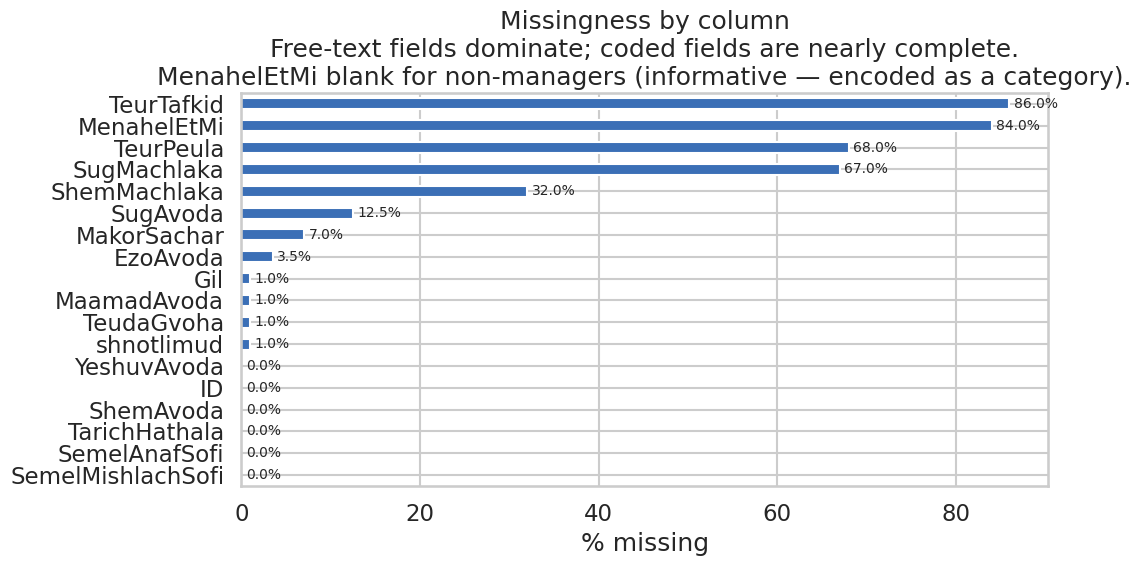

In [5]:
miss = (df.isna().sum().to_frame('n_missing')
          .assign(pct=lambda x: (x.n_missing/len(df)*100).round(1))
          .sort_values('pct', ascending=False))
fig, ax = plt.subplots(figsize=(11, 6))
miss['pct'].plot.barh(ax=ax, color='#3b6fb6'); ax.invert_yaxis()
ax.set_xlabel('% missing')
ax.set_title('Missingness by column\n'
             'Free-text fields dominate; coded fields are nearly complete.\n'
             'MenahelEtMi blank for non-managers (informative — encoded as a category).')
for i, v in enumerate(miss['pct'].values):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout(); plt.savefig(FIGDIR/'eda_missingness.png', dpi=120, bbox_inches='tight'); plt.show()


### 1.2 Target distribution & singleton classes

Histogram of *samples per class* (X-axis) versus *number of classes that
have that count* (Y-axis). The spike at 1 represents codes that appear
exactly once — they cannot be split between train and validation by any
stratified scheme. Stage 3 deals with this by stratifying on a derived
**frequency bucket**, not on the full 62-way target.


Total labelled rows : 200
Unique target codes : 62
Singleton classes   : 25


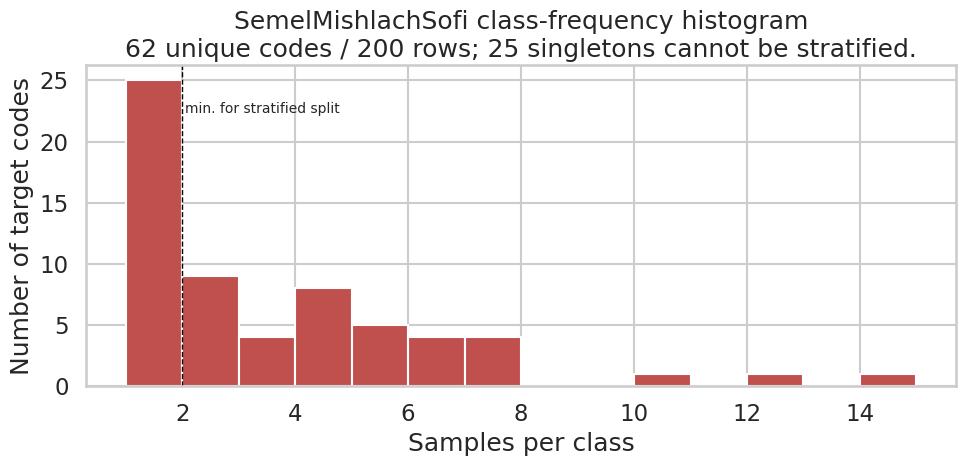

In [6]:
tgt = df['SemelMishlachSofi'].dropna()
vc  = tgt.value_counts()
n_classes = tgt.nunique()
print(f'Total labelled rows : {len(tgt)}')
print(f'Unique target codes : {n_classes}')
print(f'Singleton classes   : {(vc == 1).sum()}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(vc.values, bins=range(1, vc.max()+2), color='#c0504d', edgecolor='white')
ax.set_xlabel('Samples per class'); ax.set_ylabel('Number of target codes')
ax.set_title(f'SemelMishlachSofi class-frequency histogram\n'
             f'{n_classes} unique codes / {len(tgt)} rows; '
             f'{(vc==1).sum()} singletons cannot be stratified.')
ax.axvline(2, ls='--', color='black', lw=1)
ax.text(2.05, ax.get_ylim()[1]*0.85, 'min. for stratified split', fontsize=10)
plt.tight_layout(); plt.savefig(FIGDIR/'eda_target_hist.png', dpi=120, bbox_inches='tight'); plt.show()


### 1.3 X-coded labels (unclassifiable by humans)

9 rows have an `X` somewhere in their target code — the human coder could
not fully classify them. Excluded from supervised training. The fraction
is reported as a diagnostic ('what % of forms cannot be classified').


In [7]:
mask_x = df['SemelMishlachSofi'].fillna('').str.contains('X', case=False)
print(f'Rows with X in target: {mask_x.sum()} ({mask_x.mean()*100:.1f}%)')
print(df.loc[mask_x, 'SemelMishlachSofi'].value_counts())


Rows with X in target: 9 (4.5%)
SemelMishlachSofi
1XXX    4
XXXX    4
335X    1
Name: count, dtype: Int64


### 1.4 Industry × Occupation co-occurrence

Each cell counts how many surveys have that (industry, occupation) pair.
Concentrated rows (a single hot cell) mean industry alone determines
occupation. Diffuse rows mean the free-text fields must do the work.
The heatmap is restricted to the 15 most populated industries × 15 most
populated occupations — a wider view becomes unreadable.


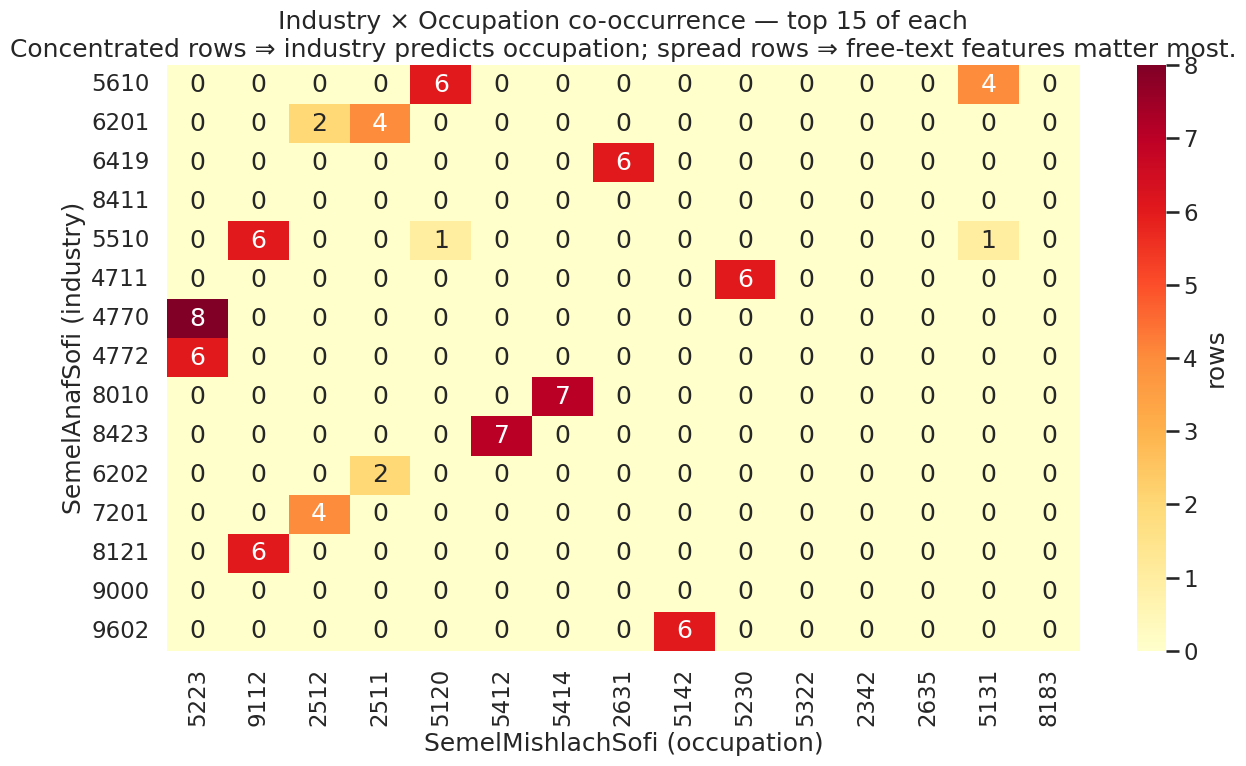

In [8]:
pivot = pd.crosstab(df['SemelAnafSofi'], df['SemelMishlachSofi'], dropna=False)
top_ind = pivot.sum(axis=1).nlargest(15).index
top_occ = pivot.sum(axis=0).nlargest(15).index
heat = pivot.loc[top_ind, top_occ]
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label':'rows'}, ax=ax)
ax.set_xlabel('SemelMishlachSofi (occupation)')
ax.set_ylabel('SemelAnafSofi (industry)')
ax.set_title('Industry × Occupation co-occurrence — top 15 of each\n'
             'Concentrated rows ⇒ industry predicts occupation; '
             'spread rows ⇒ free-text features matter most.')
plt.tight_layout(); plt.savefig(FIGDIR/'eda_pivot_industry_occupation.png', dpi=120,
                                bbox_inches='tight'); plt.show()


## 2. Preprocessing

Build the inputs that every model in Stage 5 will consume.

**Differences from the cascade pipeline:** no digit decomposition of the
target — we keep `y_full` (the original 4-digit string) and an `is_x`
flag, nothing else. The codes are treated as opaque categorical labels.

Steps:
1. Forward-fill `כנ"ל` ("same as above") across consecutive text fields.
2. Build a *tagged* document (for TF-IDF) and a *prose* document (for
   sentence embeddings) per row.
3. Mark X-coded rows so they can be excluded from training.
4. Define the tabular columns and a derived `tenure_years` from the
   start date.


In [9]:
TEXT_FIELDS = ['ShemAvoda','SugAvoda','ShemMachlaka','SugMachlaka',
               'EzoAvoda','TeurPeula','TeurTafkid']
KENAL = 'כנ"ל'
LABELS_EN = {
    'ShemAvoda':'Workplace name', 'SugAvoda':'Workplace activity',
    'ShemMachlaka':'Department', 'SugMachlaka':'Department activity',
    'EzoAvoda':'Job description', 'TeurPeula':'Main actions', 'TeurTafkid':'Job title',
}

df_proc = df.copy()

# Forward-fill כנ"ל from the logically prior text field. Cast to plain str
# first to dodge the pandas StringDtype/BooleanArray indexing trap.
for prev, nxt in zip(TEXT_FIELDS, TEXT_FIELDS[1:]):
    nxt_vals = df_proc[nxt].fillna('').astype(str)
    mask = nxt_vals.str.contains(KENAL, na=False).to_numpy(dtype=bool)
    df_proc.loc[mask, nxt] = df_proc.loc[mask, prev]

remaining = {f: int(df_proc[f].fillna('').astype(str).str.contains(KENAL, na=False).sum())
             for f in TEXT_FIELDS}
print('Remaining כנ"ל occurrences after forward-fill:', remaining)


Remaining כנ"ל occurrences after forward-fill: {'ShemAvoda': 0, 'SugAvoda': 0, 'ShemMachlaka': 0, 'SugMachlaka': 0, 'EzoAvoda': 0, 'TeurPeula': 0, 'TeurTafkid': 0}


In [10]:
# Tagged document — for TF-IDF. The square-bracket field markers are just
# ordinary tokens to TF-IDF, so adjacent character n-grams capture the
# field boundary as positional context ("the words right after [EzoAvoda]").
def make_tagged(row):
    parts = [f'[{c}] {row[c]}' for c in TEXT_FIELDS
             if pd.notna(row[c]) and str(row[c]).strip()]
    return ' '.join(parts) if parts else ''

# Prose document — for sentence embedders, which are pre-trained on natural
# language and stumble on bracket markup. The 'passage:' prefix is what the
# multilingual-E5 family expects.
def make_prose(row):
    parts = [f'{LABELS_EN[c]}: {row[c]}.' for c in TEXT_FIELDS
             if pd.notna(row[c]) and str(row[c]).strip()]
    body = ' '.join(parts)
    return 'passage: ' + body if body else 'passage: '

df_proc['_doc_tagged'] = df_proc.apply(make_tagged, axis=1)
df_proc['_doc_prose']  = df_proc.apply(make_prose,  axis=1)

# Flag X-coded rows; we'll exclude them from training but keep them for
# diagnostics.
df_proc['is_x'] = (df_proc['SemelMishlachSofi'].fillna('').astype(str)
                    .str.contains('X', case=False, na=False)
                    .to_numpy(dtype=bool))

# Drop rows with no target at all — they help neither training nor evaluation.
df_proc = df_proc.loc[df_proc['SemelMishlachSofi'].notna()].reset_index(drop=True)
print(f'Rows retained: {len(df_proc)}  (X-coded: {df_proc["is_x"].sum()})')

print(df_proc.loc[0, '_doc_tagged'][:200])
print('---')
print(df_proc.loc[0, '_doc_prose'][:200])


Rows retained: 200  (X-coded: 9)
[ShemAvoda] למ"ס [SugAvoda] איסוף, עיבוד ופרסום נתונים [ShemMachlaka] מיקרו כלכלה [SugMachlaka] טיפול בנתוני מיקרו [EzoAvoda] סגן מנהל אגף [TeurPeula] סגן מנהל אגף [TeurTafkid] סגן מנהל אגף
---
passage: Workplace name: למ"ס. Workplace activity: איסוף, עיבוד ופרסום נתונים. Department: מיקרו כלכלה. Department activity: טיפול בנתוני מיקרו. Job description: סגן מנהל אגף. Main actions: סגן מנהל א


In [11]:
# Tabular feature columns and a derived tenure_years.
df_proc['tenure_years'] = (
    (pd.Timestamp('today') - df_proc['TarichHathala']).dt.days / 365.25
).round(2)

NUM_COLS = ['shnotlimud', 'Gil', 'tenure_years']
CAT_COLS = ['MenahelEtMi','MaamadAvoda','MakorSachar','TeudaGvoha',
            'SemelAnafSofi','YeshuvAvoda']
df_proc[NUM_COLS].describe()


,shnotlimud,Gil,tenure_years
count,198.0,198.0,200.000000
mean,14.313131,39.454545,8.827600
std,2.917291,12.611149,8.366033
min,7.0,22.0,-0.080000
25%,12.0,31.0,3.490000
50%,14.0,37.0,4.100000
75%,16.0,46.0,14.497500
max,22.0,78.0,26.920000


## 3. Train / test split + 5-fold CV

Stratifying directly on the 62-way target is impossible (25 singletons).
The cascade pipeline avoided this by stratifying on `y_d1`, but that
leaks hierarchy knowledge.

We stratify on a **derived frequency bucket**:

1. Identify the top-K most populous codes — each becomes its own stratum.
2. Bucket every other code into a single `'rare'` stratum.
3. Stratify the 80/20 hold-out and the 5-fold CV on this `K+1`-level
   grouping.
4. **Verification gate** — assert that train and test each cover ≥80% of
   the unique class labels. If not, reseed and try again.

K is chosen so the smallest popular stratum still has ≥ N_FOLDS+1 = 6
members; this guarantees CV folds are well-formed.


In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold

N_FOLDS = 5
MIN_PER_BIN = N_FOLDS + 1   # so every bin survives the 5-fold split

def frequency_bin(y, min_per_bin=MIN_PER_BIN, rare_label='rare'):
    """Return a Series of stratification bins derived from class frequency.
    Classes with at least `min_per_bin` rows keep their own label; the rest
    collapse into a single 'rare' bucket. No external knowledge of the codes."""
    counts = pd.Series(y).value_counts()
    popular = set(counts[counts >= min_per_bin].index)
    return pd.Series([c if c in popular else rare_label for c in y], index=range(len(y)))

y_all = df_proc['SemelMishlachSofi'].values
strata_all = frequency_bin(y_all)
print('Frequency-bin sizes:'); print(strata_all.value_counts().head(15))
print(f'Number of distinct strata: {strata_all.nunique()}')

# 80/20 hold-out split, stratified by the frequency bin.
all_idx = np.arange(len(df_proc))
for seed_attempt in range(20):
    train_idx, test_idx = train_test_split(
        all_idx, test_size=0.20, stratify=strata_all,
        random_state=RANDOM_SEED + seed_attempt,
    )
    cov_tr = pd.Series(y_all[train_idx]).nunique() / pd.Series(y_all).nunique()
    cov_te = pd.Series(y_all[test_idx ]).nunique() / pd.Series(y_all).nunique()
    if cov_tr >= 0.80 and cov_te >= 0.30:
        break
print(f'Train covers {cov_tr:.0%} of distinct codes;  Test covers {cov_te:.0%}.')

df_tr = df_proc.iloc[train_idx].reset_index(drop=True)
df_te = df_proc.iloc[test_idx ].reset_index(drop=True)
print(f'Train: {len(df_tr)}   Test: {len(df_te)}')

# 5-fold StratifiedKFold inside the train set, on the same frequency bin.
strata_tr = frequency_bin(df_tr['SemelMishlachSofi'].values)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
folds = list(skf.split(df_tr, strata_tr.values))
for i, (tr, va) in enumerate(folds):
    print(f'  fold {i}: train {len(tr)}  val {len(va)}')


Frequency-bin sizes:
rare    112
5223     14
9112     12
2512     10
5120      7
5412      7
5414      7
2511      7
5322      6
5230      6
2631      6
5142      6
Name: count, dtype: int64
Number of distinct strata: 12
Train covers 94% of distinct codes;  Test covers 47%.
Train: 160   Test: 40
  fold 0: train 128  val 32
  fold 1: train 128  val 32
  fold 2: train 128  val 32
  fold 3: train 128  val 32
  fold 4: train 128  val 32


## 4. Feature builders

Three reusable building blocks — exactly the same as the cascade pipeline
(the feature engineering doesn't depend on hierarchy):

- `build_text_vectorizer()` — TF-IDF on `_doc_tagged`, character n-grams
  (3–5) with word boundaries. Character-level handles Hebrew morphology
  (root-sharing across `מורה`, `המורה`, `למורה`) without a morphological
  analyser.
- `build_tabular_pipeline()` — one-hot for categoricals (NaN as its own
  category — `MenahelEtMi` blank means "not a manager"); median-impute +
  scale for numerics. Returns sparse.
- Optional E5 sentence-embedding cache (Stage 5.5).


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack, csr_matrix

def build_text_vectorizer():
    """Char-n-gram TF-IDF, robust to Hebrew morphology and short text."""
    return TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5),
        min_df=2, max_features=20000, sublinear_tf=True,
    )

def build_tabular_pipeline():
    """Categoricals: one-hot (NaN handled upstream as the literal 'NaN' string).
    Numerics: median-impute + scale (no centring, so output stays sparse)."""
    cat = OneHotEncoder(handle_unknown='ignore')
    num = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ('cat', cat, CAT_COLS),
        ('num', num, NUM_COLS),
    ])


In [14]:
# Defensive cast — kills any pd.NA stragglers before sklearn touches them.
# pd.NA in a nullable column survives astype(object); only this map-based
# pass guarantees plain Python strs / np.nan floats.
def _to_str_or_nan_marker(v):
    return 'NaN' if pd.isna(v) else str(v)

for c in CAT_COLS:
    df_tr[c] = df_tr[c].map(_to_str_or_nan_marker).astype(object)
    df_te[c] = df_te[c].map(_to_str_or_nan_marker).astype(object)
for c in NUM_COLS:
    df_tr[c] = pd.to_numeric(df_tr[c], errors='coerce').astype('float64')
    df_te[c] = pd.to_numeric(df_te[c], errors='coerce').astype('float64')

assert not df_tr[CAT_COLS + NUM_COLS].map(lambda v: v is pd.NA).any().any(), \
    'pd.NA leaked into a column sklearn will scan'
print('CAT_COLS:', {c: str(df_tr[c].dtype) for c in CAT_COLS})
print('NUM_COLS:', {c: str(df_tr[c].dtype) for c in NUM_COLS})


CAT_COLS: {'MenahelEtMi': 'object', 'MaamadAvoda': 'object', 'MakorSachar': 'object', 'TeudaGvoha': 'object', 'SemelAnafSofi': 'object', 'YeshuvAvoda': 'object'}
NUM_COLS: {'shnotlimud': 'float64', 'Gil': 'float64', 'tenure_years': 'float64'}


In [15]:
# --- Optional: sentence embeddings (E5 base). Cached to disk after first run. ---
# Flip RUN_EMBEDDINGS to True to also train the embeddings + LR head model.
# The model is ~270 MB; on a Colab T4 GPU runtime the encode pass takes a few
# seconds. On CPU it takes a couple of minutes.
RUN_EMBEDDINGS = False
EMB_CACHE = ARTDIR / 'embeddings_e5.npz'

def make_emb_features(prose_series, batch_size=32):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('intfloat/multilingual-e5-base')
    return model.encode(
        prose_series.tolist(), batch_size=batch_size,
        show_progress_bar=True, normalize_embeddings=True,
    )

if RUN_EMBEDDINGS:
    if EMB_CACHE.exists():
        z = np.load(EMB_CACHE)
        emb_tr, emb_te = z['tr'], z['te']
        print('loaded cached embeddings')
    else:
        emb_tr = make_emb_features(df_tr['_doc_prose'])
        emb_te = make_emb_features(df_te['_doc_prose'])
        np.savez_compressed(EMB_CACHE, tr=emb_tr, te=emb_te)
        print('cached embeddings to', EMB_CACHE)
    print('embedding shape (train):', emb_tr.shape)


## 5. Models

Each `fit_*` function returns the same dict shape:

- `'oof'` — out-of-fold probability matrix `(n_train, n_classes)` from
  5-fold CV. Used for cross-validated metrics in Stage 6.
- `'classes'` — array of class labels indexing the columns of `oof`.
- `'final'` — model fitted on the full training set, used for predictions
  on the held-out test set.
- `'name'` — display name for the comparison table.

Class imbalance is handled via `class_weight='balanced'` in the parametric
models (LR, LightGBM). `KNeighborsClassifier` has no class-weight parameter,
so k-NN's imbalance handling is implicit through cosine similarity. No
oversampling — duplicating singletons in this dataset would only invite
memorisation.


### 5.0 Baseline — most-frequent occupation per industry

Lookup table built from the training data: for each `SemelAnafSofi`
(industry) value, store the most common `SemelMishlachSofi` (occupation).
At inference time, look up the industry and return the stored occupation
(or the global mode if the industry is unseen).

This is a pure two-column joint distribution — no schema knowledge,
and a strict floor every learned model must clear.


In [16]:
class IndustryModeBaseline:
    """Return the most-frequent SemelMishlachSofi within each SemelAnafSofi."""
    def fit(self, df, y):
        s   = pd.Series(y).reset_index(drop=True)
        ind = pd.Series(df['SemelAnafSofi'].values).reset_index(drop=True)
        joined = pd.DataFrame({'ind': ind, 'y': s})
        self.lookup_      = (joined.groupby('ind')['y']
                                   .agg(lambda x: x.value_counts().idxmax()))
        self.global_mode_ = s.value_counts().idxmax()
        return self
    def predict(self, df):
        return (pd.Series(df['SemelAnafSofi'].values)
                  .map(self.lookup_).fillna(self.global_mode_).values)


### 5.1 Core LR block — `TextTabularLR`

TF-IDF text + tabular one-hot + L2-regularised Logistic Regression. The
core building block reused by Models 5.2 and (optionally) 5.5.


In [17]:
from sklearn.linear_model import LogisticRegression

class TextTabularLR:
    """Concatenate TF-IDF (sparse) and tabular one-hot (sparse) features,
    then fit Logistic Regression with class_weight='balanced'."""
    def __init__(self, C=1.0):
        self.tfidf = build_text_vectorizer()
        self.tab   = build_tabular_pipeline()
        self.clf   = LogisticRegression(max_iter=2000, class_weight='balanced',
                                        C=C, n_jobs=-1)
    def _stack(self, df, fit=False):
        Xt = (self.tfidf.fit_transform(df['_doc_tagged']) if fit
              else self.tfidf.transform(df['_doc_tagged']))
        Xb = self.tab.fit_transform(df) if fit else self.tab.transform(df)
        return hstack([Xt, Xb]).tocsr()
    def fit(self, df, y):
        X = self._stack(df, fit=True)
        self.clf.fit(X, y)
        self.classes_ = self.clf.classes_
        return self
    def predict_proba(self, df): return self.clf.predict_proba(self._stack(df))
    def predict(self, df):       return self.clf.predict(self._stack(df))


### 5.2 LR flat — direct 62-way prediction


In [18]:
def fit_flat(df_tr, y_full, folds, C=1.0):
    """5-fold OOF probabilities + a final LR model fitted on all clean rows."""
    n = len(df_tr)
    y = pd.Series(y_full).reset_index(drop=True)
    is_x = (y.fillna('').astype(str)
             .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    not_na = y.notna().to_numpy(dtype=bool)
    mask = (~is_x) & not_na   # train on rows with a clean 4-digit label

    classes = np.array(sorted(y[mask].unique()))
    cls2idx = {c: i for i, c in enumerate(classes)}
    oof = np.zeros((n, len(classes)))
    oof_filled = np.zeros(n, dtype=bool)
    for tr, va in folds:
        tr_k = [i for i in tr if mask[i]]
        va_k = [i for i in va if mask[i]]
        if not tr_k or not va_k: continue
        m = TextTabularLR(C=C).fit(df_tr.iloc[tr_k].reset_index(drop=True),
                                   y.iloc[tr_k].values)
        p = m.predict_proba(df_tr.iloc[va_k].reset_index(drop=True))
        for ci, cls in enumerate(m.classes_):
            if cls in cls2idx:
                oof[va_k, cls2idx[cls]] = p[:, ci]
        oof_filled[va_k] = True
    final = TextTabularLR(C=C).fit(df_tr.iloc[mask].reset_index(drop=True),
                                   y[mask].values)
    return {'oof': oof, 'classes': classes, 'oof_filled': oof_filled,
            'final': final, 'name': 'LR flat'}


### 5.3 LightGBM flat — TF-IDF + tabular gradient boosting

Captures non-linear interactions linear LR cannot — e.g. "hospital
industry **and** age > 50" as a joint condition. Trees handle missingness
and feature scaling natively. Tightly regularised because the input is
high-dimensional sparse text and the dataset is tiny.


In [19]:
import lightgbm as lgb

def fit_lgb_flat(df_tr, y_full, folds):
    """LightGBM on TF-IDF + tabular features.
    Honest OOF: TF-IDF + tabular transformers are refit per fold on the
    fold's training slice only — the OOF rows do not contribute to the
    vocabulary or to the OneHotEncoder's category list."""
    n = len(df_tr)
    y = pd.Series(y_full).reset_index(drop=True)
    is_x_arr = (y.fillna('').astype(str)
                 .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    not_na = y.notna().to_numpy(dtype=bool)
    mask = (~is_x_arr) & not_na

    classes = np.array(sorted(y[mask].unique()))
    cls2idx = {c: i for i, c in enumerate(classes)}

    def _make_clf():
        return lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            num_leaves=31, min_data_in_leaf=5,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
            class_weight='balanced', verbose=-1, n_jobs=-1)

    # === Per-fold OOF — refit feature pipeline inside each fold ===
    oof = np.zeros((n, len(classes)))
    for tr, va in folds:
        tr_k = [i for i in tr if mask[i]]
        va_k = [i for i in va if mask[i]]
        if not tr_k or not va_k:
            continue
        df_tr_fold = df_tr.iloc[tr_k].reset_index(drop=True)
        df_va_fold = df_tr.iloc[va_k].reset_index(drop=True)
        tfidf_f = build_text_vectorizer().fit(df_tr_fold['_doc_tagged'])
        tab_f   = build_tabular_pipeline().fit(df_tr_fold)
        X_tr = hstack([tfidf_f.transform(df_tr_fold['_doc_tagged']),
                       tab_f.transform(df_tr_fold)]).tocsr()
        X_va = hstack([tfidf_f.transform(df_va_fold['_doc_tagged']),
                       tab_f.transform(df_va_fold)]).tocsr()
        clf = _make_clf().fit(X_tr, y.iloc[tr_k].values)
        p = clf.predict_proba(X_va)
        for ci, cls in enumerate(clf.classes_):
            if cls in cls2idx:
                oof[va_k, cls2idx[cls]] = p[:, ci]

    # === Final model — refit transformers on the full clean training set ===
    df_full = df_tr.iloc[mask].reset_index(drop=True)
    tfidf_full = build_text_vectorizer().fit(df_full['_doc_tagged'])
    tab_full   = build_tabular_pipeline().fit(df_full)
    X_full = hstack([tfidf_full.transform(df_full['_doc_tagged']),
                     tab_full.transform(df_full)]).tocsr()
    final = _make_clf().fit(X_full, y[mask].values)

    return {'oof': oof, 'classes': classes, 'final': final,
            'tfidf': tfidf_full, 'tab': tab_full, 'name': 'LightGBM flat'}


### 5.4 k-Nearest-Neighbours (k-NN) flat — *new model*

Non-parametric retrieval: at inference time, find the k closest training
rows in feature space and vote on their labels (weighted by similarity).
Replaces the cascade as the methodology variety pick.

Why it makes sense at this size:

- 200 rows are too few to learn 62 classes parametrically; **memorising +
  retrieving** is sometimes a better fit.
- Cosine distance on TF-IDF + one-hot features captures the intuition
  that two surveys describing similar workplaces likely share an
  occupation code.
- It uses *zero* hierarchy assumption — a perfect contrast to LR / LightGBM.

Probabilities come from `predict_proba`, which sklearn's KNN computes from
the weighted vote distribution among the k nearest neighbours.


In [20]:
from sklearn.neighbors import KNeighborsClassifier

def fit_knn_flat(df_tr, y_full, folds, k=5):
    """Cosine-distance k-NN with distance-weighted votes.
    Honest OOF: TF-IDF + tabular transformers are refit per fold on the
    fold's training slice only.

    Note: KNeighborsClassifier has no class_weight parameter; class imbalance
    is handled implicitly via cosine similarity (rare-class neighbours get
    surfaced when their text is sufficiently similar)."""
    n = len(df_tr)
    y = pd.Series(y_full).reset_index(drop=True)
    is_x_arr = (y.fillna('').astype(str)
                 .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    not_na = y.notna().to_numpy(dtype=bool)
    mask = (~is_x_arr) & not_na

    classes = np.array(sorted(y[mask].unique()))
    cls2idx = {c: i for i, c in enumerate(classes)}

    def _make_clf():
        return KNeighborsClassifier(
            n_neighbors=k, metric='cosine', weights='distance',
            n_jobs=-1)

    # === Per-fold OOF — refit feature pipeline inside each fold ===
    oof = np.zeros((n, len(classes)))
    for tr, va in folds:
        tr_k = [i for i in tr if mask[i]]
        va_k = [i for i in va if mask[i]]
        if not tr_k or not va_k:
            continue
        df_tr_fold = df_tr.iloc[tr_k].reset_index(drop=True)
        df_va_fold = df_tr.iloc[va_k].reset_index(drop=True)
        tfidf_f = build_text_vectorizer().fit(df_tr_fold['_doc_tagged'])
        tab_f   = build_tabular_pipeline().fit(df_tr_fold)
        X_tr = hstack([tfidf_f.transform(df_tr_fold['_doc_tagged']),
                       tab_f.transform(df_tr_fold)]).tocsr()
        X_va = hstack([tfidf_f.transform(df_va_fold['_doc_tagged']),
                       tab_f.transform(df_va_fold)]).tocsr()
        clf = _make_clf().fit(X_tr, y.iloc[tr_k].values)
        p = clf.predict_proba(X_va)
        for ci, cls in enumerate(clf.classes_):
            if cls in cls2idx:
                oof[va_k, cls2idx[cls]] = p[:, ci]

    # === Final model — refit transformers on the full clean training set ===
    df_full = df_tr.iloc[mask].reset_index(drop=True)
    tfidf_full = build_text_vectorizer().fit(df_full['_doc_tagged'])
    tab_full   = build_tabular_pipeline().fit(df_full)
    X_full = hstack([tfidf_full.transform(df_full['_doc_tagged']),
                     tab_full.transform(df_full)]).tocsr()
    final = _make_clf().fit(X_full, y[mask].values)

    return {'oof': oof, 'classes': classes, 'final': final,
            'tfidf': tfidf_full, 'tab': tab_full, 'name': f'k-NN (k={k})'}


### 5.5 (Optional) Frozen embeddings + LR head

Replaces TF-IDF with multilingual sentence embeddings. Only runs when
`RUN_EMBEDDINGS = True` (Stage 4).


In [21]:
def fit_emb_lr(df_tr, y_full, folds, emb_tr_array):
    """Same fit_flat surface, but the text features are dense E5 embeddings."""
    n = len(df_tr)
    y = pd.Series(y_full).reset_index(drop=True)
    is_x_arr = (y.fillna('').astype(str)
                 .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    not_na = y.notna().to_numpy(dtype=bool)
    mask = (~is_x_arr) & not_na
    classes = np.array(sorted(y[mask].unique()))
    cls2idx = {c: i for i, c in enumerate(classes)}

    tab = build_tabular_pipeline().fit(df_tr)
    X_tab = tab.transform(df_tr)
    X_all = hstack([csr_matrix(emb_tr_array), X_tab]).tocsr()

    def _make_clf():
        return LogisticRegression(max_iter=2000, class_weight='balanced',
                                  C=1.0, n_jobs=-1)

    oof = np.zeros((n, len(classes)))
    for tr, va in folds:
        tr_k = [i for i in tr if mask[i]]
        va_k = [i for i in va if mask[i]]
        if not tr_k or not va_k: continue
        clf = _make_clf().fit(X_all[tr_k], y.iloc[tr_k].values)
        p = clf.predict_proba(X_all[va_k])
        for ci, cls in enumerate(clf.classes_):
            if cls in cls2idx:
                oof[va_k, cls2idx[cls]] = p[:, ci]
    final = _make_clf().fit(X_all[mask], y[mask].values)
    return {'oof': oof, 'classes': classes, 'final': final,
            'tab': tab, 'name': 'Embeddings + LR'}


### 5.6 Soft-vote ensemble — *new*

Probability average across the parametric models (LR, LightGBM, k-NN, and
Embeddings if enabled). Each model's probability matrix is *aligned* to
the union of class labels first, then averaged.

Why ensemble: the four base models err in genuinely different ways (linear
softmax / tree splits / nearest-neighbour vote / dense semantics). Soft
voting reduces variance with no extra training and is hard to make worse
than the best base model.

We additionally compute a **top-3 union** ranking — for each row, take
each base model's top-3 predictions, union them, then re-rank by the
ensemble probability. This often boosts the operationally relevant top-3
hit rate.


In [22]:
def aligned_proba(P, src_classes, all_classes):
    """Reshape (n, |src_classes|) to (n, |all_classes|), zero-padding new columns."""
    out = np.zeros((P.shape[0], len(all_classes)))
    idx = {c: i for i, c in enumerate(all_classes)}
    for j, c in enumerate(src_classes):
        if c in idx:
            out[:, idx[c]] = P[:, j]
    return out

def soft_vote(results_dict, base_keys):
    """Average probability matrices across `base_keys` over a unioned class space."""
    union = sorted(set().union(*[set(results_dict[k]['classes']) for k in base_keys]))
    union_arr = np.array(union)
    aligned = [aligned_proba(results_dict[k]['oof'],
                             results_dict[k]['classes'],
                             union_arr) for k in base_keys]
    return np.mean(np.stack(aligned), axis=0), union_arr


### 5.7 Fit all models

One driver cell. After it runs, `results` holds the OOF probabilities and
fitted final models for every approach.


In [23]:
import time
results = {}
y_tr = df_tr['SemelMishlachSofi'].values
y_te = df_te['SemelMishlachSofi'].values

t0 = time.time()
baseline = IndustryModeBaseline().fit(df_tr, y_tr)
print(f'Baseline fitted in {time.time()-t0:.1f}s')

t0 = time.time(); results['flat'] = fit_flat(df_tr, y_tr, folds)
print(f"LR flat fitted in {time.time()-t0:.1f}s")

t0 = time.time(); results['lgb'] = fit_lgb_flat(df_tr, y_tr, folds)
print(f"LightGBM fitted in {time.time()-t0:.1f}s")

t0 = time.time(); results['knn'] = fit_knn_flat(df_tr, y_tr, folds, k=5)
print(f"k-NN fitted in {time.time()-t0:.1f}s")

if RUN_EMBEDDINGS:
    t0 = time.time(); results['emb'] = fit_emb_lr(df_tr, y_tr, folds, emb_tr)
    print(f"Embeddings + LR fitted in {time.time()-t0:.1f}s")

# Ensemble: average probabilities across the parametric models.
BASES = ['flat', 'lgb', 'knn'] + (['emb'] if RUN_EMBEDDINGS else [])
ens_oof, ens_classes = soft_vote(results, BASES)
results['ensemble'] = {'oof': ens_oof, 'classes': ens_classes,
                        'name': 'Soft-vote ensemble', 'final': None,
                        'bases': BASES}
print(f'Ensemble of {BASES} computed; class space size {len(ens_classes)}')


Baseline fitted in 0.1s
LR flat fitted in 35.1s
LightGBM fitted in 48.5s
k-NN fitted in 0.2s
Ensemble of ['flat', 'lgb', 'knn'] computed; class space size 56


## 6. Evaluation — extended metric block

Every model produces the same metric block, computed on the **OOF**
predictions (the honest small-data CV estimate). None of these metrics
assume hierarchy.

| Metric | Single number? | What it tells you |
|---|---|---|
| top-1 accuracy | ✓ | Headline. |
| top-3 accuracy | ✓ | Operational metric — model proposes 3 codes, coder picks one. |
| macro-F1 | ✓ | Imbalance-aware: every class counted equally. |
| weighted-F1 | ✓ | Support-weighted; closer to accuracy. |
| macro one-vs-rest **ROC AUC** | ✓ | Threshold-free discrimination (caveat: optimistic under heavy imbalance). |
| macro one-vs-rest **PR-AUC** | ✓ | More honest than ROC for this skew. |
| **Cohen's κ** (unweighted) | ✓ | Chance-corrected accuracy. |
| **Cohen's κ_quadratic** | ✓ | Penalises wrong predictions less when their *integer-encoded code* is closer to the truth — a hierarchy proxy that doesn't *name* the hierarchy. |
| **Brier score** | ✓ | Quality of probabilities (mean squared error against one-hot truth). |
| **Log-loss** | ✓ | Cross-entropy; rewards calibrated confidence. |
| **ECE** (Expected Calibration Error) | ✓ | Distance from perfect calibration; load-bearing for the threshold rule. |

All single-number metrics are stored in `df_results`. Plots live in Stage 7.


In [24]:
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                              cohen_kappa_score, log_loss)
from sklearn.preprocessing import label_binarize

def _topk_classes(probs, classes, k=1):
    idx = np.argsort(-probs, axis=1)[:, :k]
    return classes[idx]

def _safe_macro_auc(y_bin, probs):
    """OvR macro-AUC, skipping classes with no positive in y."""
    keep = y_bin.sum(axis=0) > 0
    if keep.sum() < 2: return np.nan
    return roc_auc_score(y_bin[:, keep], probs[:, keep], average='macro')

def _safe_macro_ap(y_bin, probs):
    keep = y_bin.sum(axis=0) > 0
    if keep.sum() < 2: return np.nan
    return average_precision_score(y_bin[:, keep], probs[:, keep], average='macro')

def _brier_multiclass(y_true, probs, classes):
    cls2idx = {c: i for i, c in enumerate(classes)}
    Y = np.zeros_like(probs)
    valid = np.zeros(len(y_true), dtype=bool)
    for i, c in enumerate(y_true):
        if c in cls2idx:
            Y[i, cls2idx[c]] = 1.0; valid[i] = True
    return float(((probs[valid] - Y[valid]) ** 2).sum(axis=1).mean()) if valid.any() else np.nan

def _ece(y_true_eq_pred, conf, n_bins=10):
    """Expected Calibration Error — quantile bins; mean |bin_acc − bin_conf|."""
    if len(conf) == 0: return np.nan
    qs = np.quantile(conf, np.linspace(0, 1, n_bins + 1))
    qs[0] -= 1e-9; qs[-1] += 1e-9
    err, total = 0.0, len(conf)
    for lo, hi in zip(qs[:-1], qs[1:]):
        in_bin = (conf >= lo) & (conf < hi)
        if in_bin.sum() == 0: continue
        bin_acc, bin_conf = y_true_eq_pred[in_bin].mean(), conf[in_bin].mean()
        err += (in_bin.sum() / total) * abs(bin_acc - bin_conf)
    return float(err)

def _kappa_q_via_int(y_true, y_pred):
    """Cohen κ with quadratic weights, encoding codes as their integer value.
    Numeric ordering on integer codes is a coarse hierarchy proxy that uses
    no schema knowledge — only the fact that the labels happen to be numeric strings."""
    def to_int(arr):
        out = []
        for v in arr:
            try: out.append(int(str(v)))
            except (TypeError, ValueError): out.append(-1)
        return np.asarray(out)
    yt, yp = to_int(y_true), to_int(y_pred)
    valid = (yt >= 0) & (yp >= 0)
    if valid.sum() < 2: return np.nan
    return float(cohen_kappa_score(yt[valid], yp[valid], weights='quadratic'))

def evaluate_model(name, y_true_full, oof_probs, classes,
                   oof_filled=None, top3=True):
    """Compute the full metric block for one model and return a row dict."""
    n = len(y_true_full)
    valid = oof_filled if oof_filled is not None else np.ones(n, bool)
    is_x = (pd.Series(y_true_full).fillna('').astype(str)
              .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    not_na = pd.Series(y_true_full).notna().to_numpy(dtype=bool)
    keep = valid & ~is_x & not_na
    yt = np.asarray(y_true_full)[keep]
    P = oof_probs[keep]
    pred_full = _topk_classes(P, classes, 1).ravel()
    row = {'model': name}
    if len(yt) == 0:
        return {**row, 'top1': np.nan, 'top3': np.nan}
    row['top1'] = float((pred_full == yt).mean())
    if top3:
        top3p = _topk_classes(P, classes, 3)
        row['top3'] = float(np.mean([yt[i] in top3p[i] for i in range(len(yt))]))
    row['macroF1']     = f1_score(yt, pred_full, average='macro')
    row['weightedF1']  = f1_score(yt, pred_full, average='weighted')
    # OvR AUC + AP need a binarised truth matrix over the model's class set.
    y_bin = label_binarize(yt, classes=list(classes))
    if y_bin.ndim == 1: y_bin = np.column_stack([1 - y_bin, y_bin])
    row['macroAUC_OvR'] = _safe_macro_auc(y_bin, P)
    row['macroAP_OvR']  = _safe_macro_ap(y_bin, P)
    row['kappa']        = float(cohen_kappa_score(yt, pred_full))
    row['kappa_q_int']  = _kappa_q_via_int(yt, pred_full)
    row['brier']        = _brier_multiclass(yt, P, classes)
    try:
        row['logloss']  = float(log_loss(yt, P, labels=list(classes)))
    except Exception:
        row['logloss']  = np.nan
    conf = P.max(axis=1)
    row['ECE'] = _ece(pred_full == yt, conf, n_bins=10)
    return row


In [25]:
rows = []

# === Baseline — same X-coded filter as the learned models so accuracies are comparable ===
bp = baseline.predict(df_tr)
is_x_tr = (pd.Series(y_tr).fillna('').astype(str)
              .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
not_na_tr = pd.Series(y_tr).notna().to_numpy(dtype=bool)
keep_tr = ~is_x_tr & not_na_tr
y_tr_v = np.asarray(y_tr)[keep_tr]
bp_v   = bp[keep_tr]

rows.append({
    'model': 'Baseline (industry mode)',
    'top1':  float((bp_v == y_tr_v).mean()),
    'top3':  np.nan, 'macroF1': np.nan, 'weightedF1': np.nan,
    'macroAUC_OvR': np.nan, 'macroAP_OvR': np.nan,
    'kappa':       float(cohen_kappa_score(y_tr_v, bp_v)),
    'kappa_q_int': _kappa_q_via_int(y_tr_v, bp_v),
    'brier': np.nan, 'logloss': np.nan, 'ECE': np.nan,
})

for key in ['flat', 'lgb', 'knn'] + (['emb'] if RUN_EMBEDDINGS else []) + ['ensemble']:
    r = results[key]
    rows.append(evaluate_model(
        r['name'], y_tr, r['oof'], r['classes'],
        oof_filled=r.get('oof_filled')))

df_results = pd.DataFrame(rows).set_index('model').round(3)
display(df_results)
df_results.to_csv(ARTDIR/'cv_results.csv')


,top1,top3,macroF1,weightedF1,macroAUC_OvR,macroAP_OvR,kappa,kappa_q_int,brier,logloss,ECE
model,,,,,,,,,,,
Baseline (industry mode),0.719,NaN,NaN,NaN,NaN,NaN,0.710,0.835,NaN,NaN,NaN
LR flat,0.724,0.776,0.434,0.670,0.570,0.449,0.715,0.883,0.569,7.687,0.365
LightGBM flat,0.718,0.763,0.461,0.701,0.574,0.490,0.710,0.917,0.438,7.177,0.166
k-NN (k=5),0.699,0.769,0.382,0.632,0.749,0.438,0.689,0.871,0.493,8.223,0.071
Soft-vote ensemble,0.750,0.782,0.460,0.712,0.574,0.503,0.742,0.944,0.396,7.216,0.189


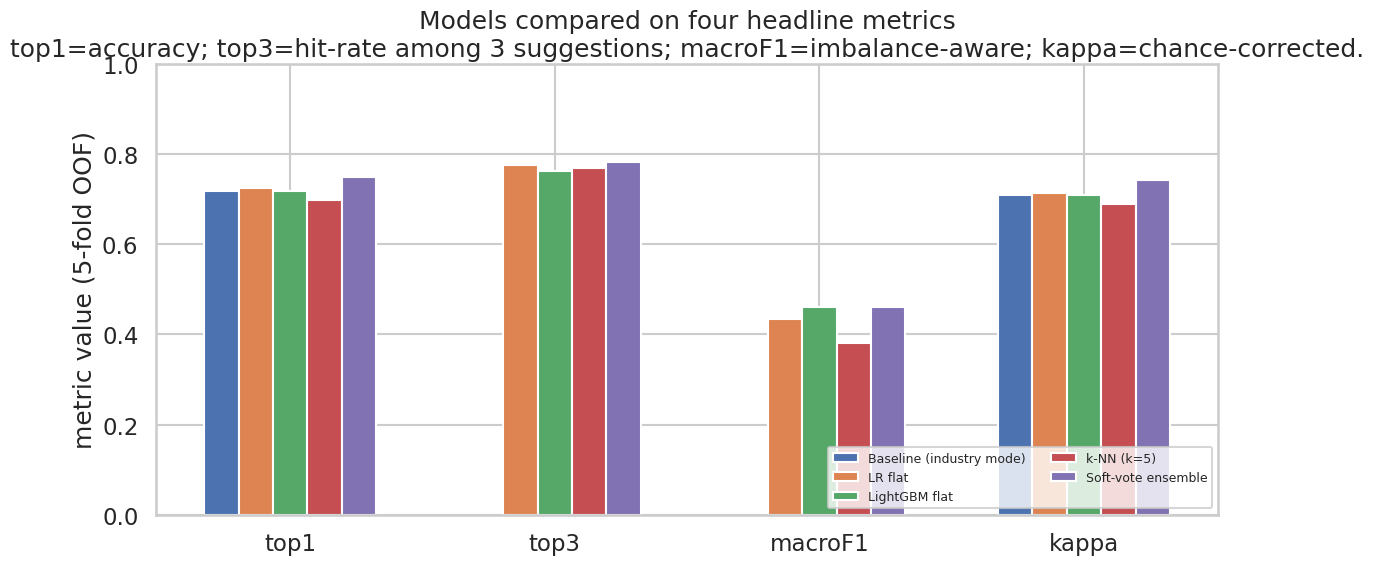

In [26]:
# Comparison bar chart — chooses the four most informative single numbers
# (top1, top3, macroF1, kappa) so the deck has one chart that tells the
# whole story at a glance.
metrics = ['top1', 'top3', 'macroF1', 'kappa']
x = np.arange(len(metrics)); w = 0.13
fig, ax = plt.subplots(figsize=(12, 6))
for i, m in enumerate(df_results.index):
    ax.bar(x + i*w - w*(len(df_results)-1)/2,
           df_results.loc[m, metrics].astype(float).values, width=w, label=m)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('metric value (5-fold OOF)')
ax.set_title('Models compared on four headline metrics\n'
             'top1=accuracy; top3=hit-rate among 3 suggestions; macroF1=imbalance-aware; '
             'kappa=chance-corrected.')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(FIGDIR/'eval_compare_metrics.png', dpi=120,
                                bbox_inches='tight'); plt.show()


### 6.1 Held-out test set (touch once)


In [27]:
# Predict on the locked test set with each final model.
test_rows = []

# Baseline — same X-coded filter as the learned models for an apples-to-apples accuracy.
bp_te = baseline.predict(df_te)
is_x_te = (pd.Series(y_te).fillna('').astype(str)
              .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
not_na_te = pd.Series(y_te).notna().to_numpy(dtype=bool)
keep_te = ~is_x_te & not_na_te
test_rows.append({
    'model': 'Baseline',
    'top1':  float((bp_te[keep_te] == np.asarray(y_te)[keep_te]).mean()),
})

def _evaluate_test(name, probs, classes):
    pred = classes[np.argmax(probs, axis=1)]
    is_x_te = (pd.Series(y_te).fillna('').astype(str)
                  .str.contains('X', case=False, na=False).to_numpy(dtype=bool))
    keep = ~is_x_te & pd.Series(y_te).notna().to_numpy(dtype=bool)
    yt = np.asarray(y_te)[keep]
    P  = probs[keep]
    top3p = _topk_classes(P, classes, 3)
    return {
        'model': name,
        'top1':  float((pred[keep] == yt).mean()),
        'top3':  float(np.mean([yt[i] in top3p[i] for i in range(len(yt))])),
        'macroF1':     f1_score(yt, pred[keep], average='macro'),
        'kappa':       float(cohen_kappa_score(yt, pred[keep])),
        'kappa_q_int': _kappa_q_via_int(yt, pred[keep]),
    }

# LR flat
p_flat_te = results['flat']['final'].predict_proba(df_te)
test_rows.append(_evaluate_test('LR flat', p_flat_te,
                                 results['flat']['final'].classes_))

# LightGBM
X_te_text = results['lgb']['tfidf'].transform(df_te['_doc_tagged'])
X_te_tab  = results['lgb']['tab'].transform(df_te)
X_te_lgb  = hstack([X_te_text, X_te_tab]).tocsr()
p_lgb_te = results['lgb']['final'].predict_proba(X_te_lgb)
test_rows.append(_evaluate_test('LightGBM flat', p_lgb_te,
                                 results['lgb']['final'].classes_))

# k-NN
X_te_knn_text = results['knn']['tfidf'].transform(df_te['_doc_tagged'])
X_te_knn_tab  = results['knn']['tab'].transform(df_te)
X_te_knn      = hstack([X_te_knn_text, X_te_knn_tab]).tocsr()
p_knn_te = results['knn']['final'].predict_proba(X_te_knn)
test_rows.append(_evaluate_test('k-NN', p_knn_te,
                                 results['knn']['final'].classes_))

# Ensemble — average over the same base models, on test predictions.
test_probs_by_key = {'flat': (p_flat_te, results['flat']['final'].classes_),
                      'lgb':  (p_lgb_te,  results['lgb']['final'].classes_),
                      'knn':  (p_knn_te,  results['knn']['final'].classes_)}
ens_classes_te = sorted(set().union(*[set(c) for _, c in test_probs_by_key.values()]))
ens_classes_te = np.array(ens_classes_te)
ens_te = np.mean(np.stack([
    aligned_proba(P, c, ens_classes_te) for P, c in test_probs_by_key.values()
]), axis=0)
test_rows.append(_evaluate_test('Soft-vote ensemble', ens_te, ens_classes_te))

df_test_results = pd.DataFrame(test_rows).set_index('model').round(3)
display(df_test_results)
df_test_results.to_csv(ARTDIR/'test_results.csv')


,top1,top3,macroF1,kappa,kappa_q_int
model,,,,,
Baseline,0.600,NaN,NaN,NaN,NaN
LR flat,0.771,0.857,0.591,0.761,0.899
LightGBM flat,0.857,0.886,0.751,0.850,0.834
k-NN,0.771,0.886,0.625,0.761,0.941
Soft-vote ensemble,0.857,0.886,0.751,0.850,0.834


## 7. Insights for the deck


### 7.1 PR curves for the top-K most populous classes

Precision-recall is more honest than ROC for heavily imbalanced
multi-class. We restrict to the 10 codes with the most training rows —
anything rarer is dominated by sampling noise. One curve per class on
one figure: easy to scan.


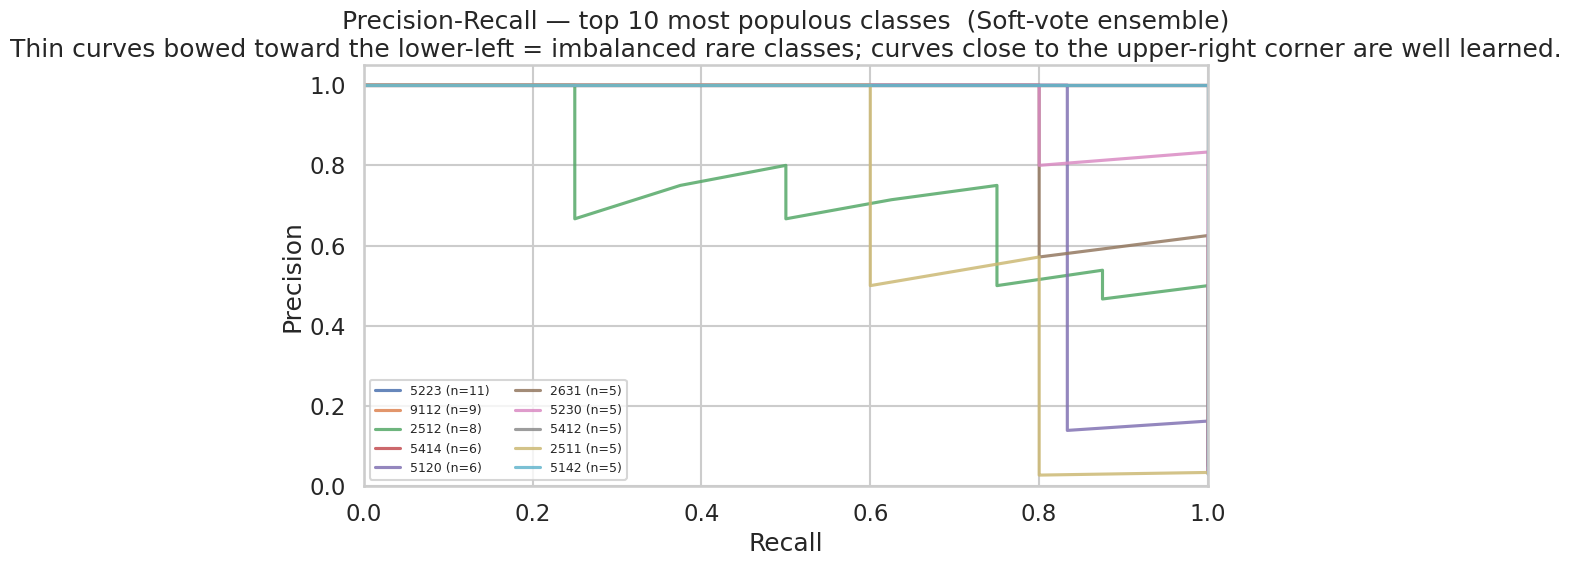

In [28]:
from sklearn.metrics import precision_recall_curve

best_key = df_results['top1'].drop('Baseline (industry mode)').astype(float).idxmax()
best_alias = {v['name']: k for k, v in results.items() if isinstance(v, dict) and 'name' in v}.get(best_key, 'flat')

P_best = results[best_alias]['oof']
C_best = results[best_alias]['classes']

vc_train = pd.Series(y_tr).value_counts()
top_classes = [c for c in vc_train.index[:10] if c in C_best]

fig, ax = plt.subplots(figsize=(10, 6))
for cls in top_classes:
    j = list(C_best).index(cls)
    y_bin = (np.asarray(y_tr) == cls).astype(int)
    p, r, _ = precision_recall_curve(y_bin, P_best[:, j])
    ax.plot(r, p, label=f'{cls} (n={vc_train[cls]})', alpha=0.85)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall — top 10 most populous classes  ({best_key})\n'
             'Thin curves bowed toward the lower-left = imbalanced rare classes; '
             'curves close to the upper-right corner are well learned.')
ax.legend(fontsize=9, loc='lower left', ncol=2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig(FIGDIR/'pr_curves.png', dpi=120, bbox_inches='tight'); plt.show()



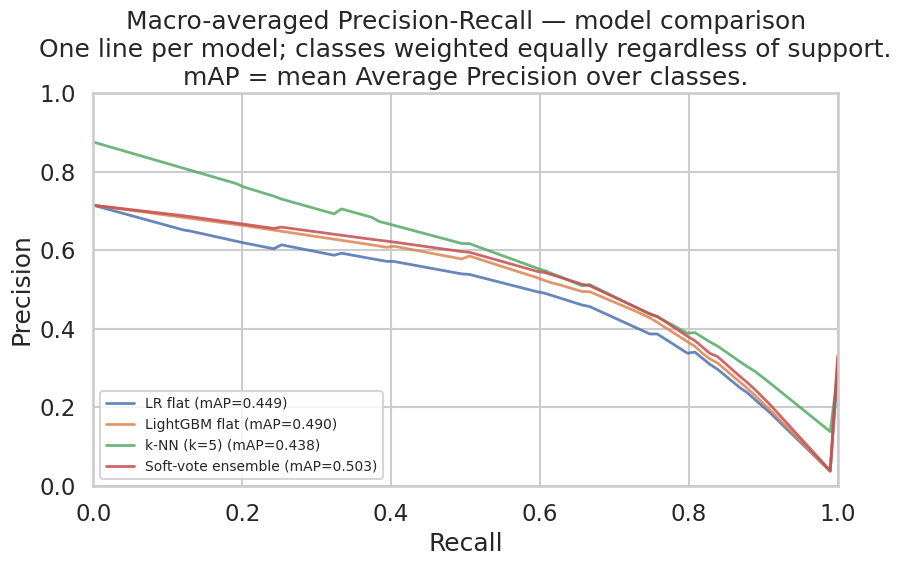

In [29]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# Build one PR curve per model, macro-averaged across the classes that
# actually appear in y_true. Plotted on a shared axis for comparison.
def macro_pr(y_true, P, classes, n_grid=100):
    """Macro-average per-class PR curves onto a common recall grid."""
    classes = list(classes)
    y_bin = label_binarize(y_true, classes=classes)
    if y_bin.ndim == 1:
        y_bin = np.column_stack([1 - y_bin, y_bin])
    keep = y_bin.sum(axis=0) > 0
    grid = np.linspace(0, 1, n_grid)
    interp = []
    for j in np.where(keep)[0]:
        p, r, _ = precision_recall_curve(y_bin[:, j], P[:, j])
        # interpolate precision onto the recall grid (PR curves go right-to-left)
        order = np.argsort(r)
        interp.append(np.interp(grid, r[order], p[order]))
    return grid, np.mean(np.stack(interp), axis=0) if interp else np.zeros_like(grid)

valid = (~df_tr['is_x'].to_numpy(bool)) & pd.Series(y_tr).notna().to_numpy(bool)
yt_v  = np.asarray(y_tr)[valid]

fig, ax = plt.subplots(figsize=(9, 6))
for key in ['flat', 'lgb', 'knn'] + (['emb'] if RUN_EMBEDDINGS else []) + ['ensemble']:
    r = results[key]
    P = r['oof'][valid]
    grid, prec = macro_pr(yt_v, P, r['classes'])
    ap = average_precision_score(
        label_binarize(yt_v, classes=list(r['classes'])), P, average='macro')
    ax.plot(grid, prec, label=f"{r['name']} (mAP={ap:.3f})", lw=2, alpha=0.85)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Macro-averaged Precision-Recall — model comparison\n'
             'One line per model; classes weighted equally regardless of support.\n'
             'mAP = mean Average Precision over classes.')
ax.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig(FIGDIR/'pr_macro_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### 7.2 Confusion matrix on the top-15 most populous classes

The full 62×62 confusion matrix is unreadable at this size. Restricting
to the 15 most-supported classes gives a usable 15×15 view; the remaining
rare classes are folded into a single `other` row/column so the totals
still add up.


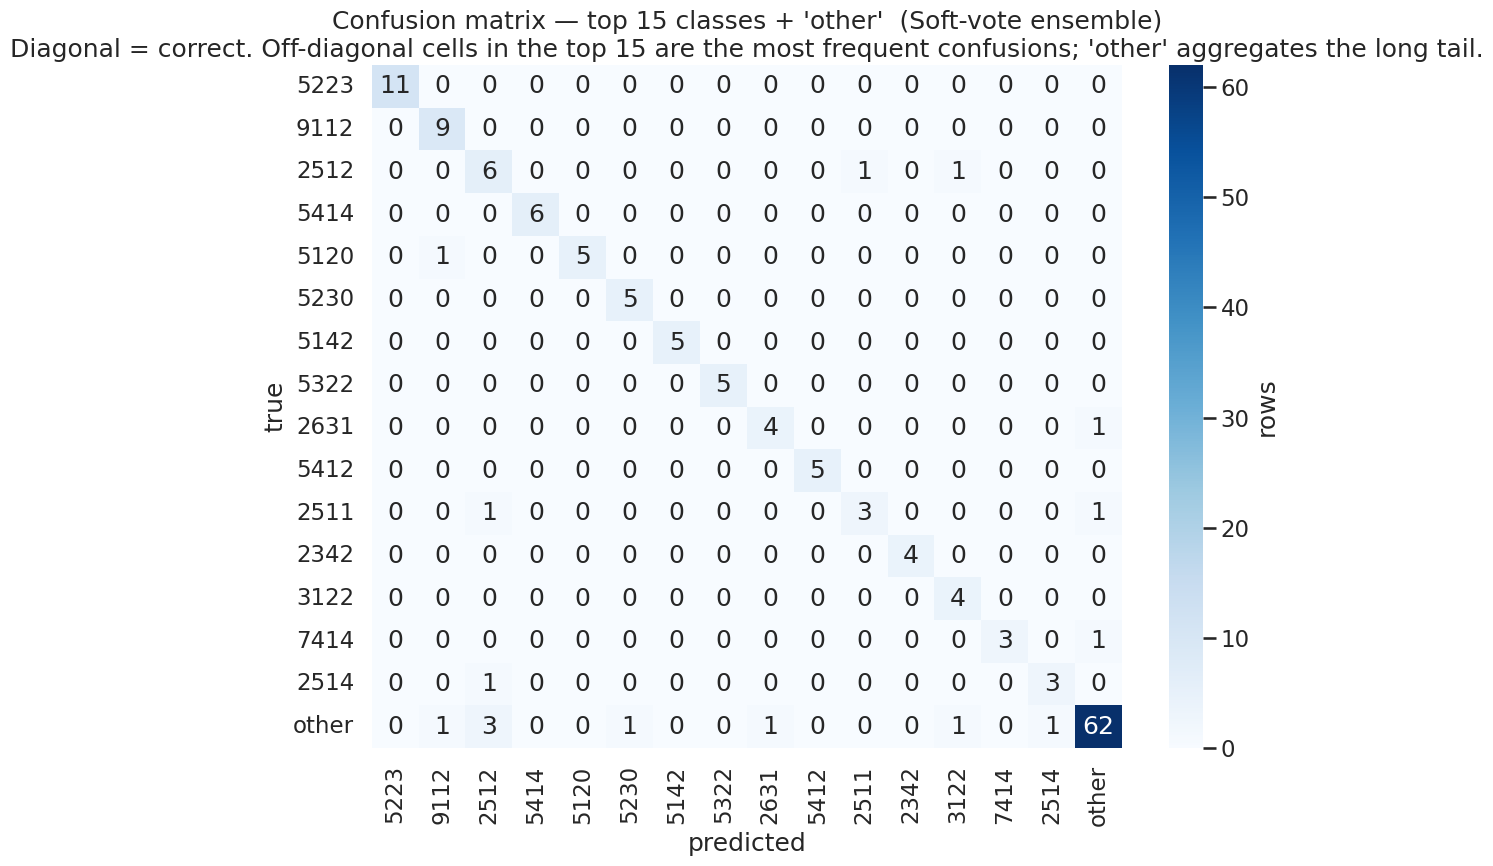

In [30]:
from sklearn.metrics import confusion_matrix

P_best = results[best_alias]['oof']
C_best = results[best_alias]['classes']
pred_best = C_best[np.argmax(P_best, axis=1)]

valid = (~df_tr['is_x'].to_numpy(dtype=bool)) & pd.Series(y_tr).notna().to_numpy(bool)
yt_v   = np.asarray(y_tr)[valid]
ypred_v = np.asarray(pred_best)[valid]

top15 = list(pd.Series(yt_v).value_counts().head(15).index)
labels = top15 + ['other']
remap = lambda arr: np.array([c if c in top15 else 'other' for c in arr])
cm = confusion_matrix(remap(yt_v), remap(ypred_v), labels=labels)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'rows'}, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Confusion matrix — top 15 classes + \'other\'  ({best_key})\n'
             'Diagonal = correct. Off-diagonal cells in the top 15 are the most '
             'frequent confusions; \'other\' aggregates the long tail.')
plt.tight_layout(); plt.savefig(FIGDIR/'confusion_top15.png', dpi=120, bbox_inches='tight'); plt.show()


### 7.3 Reliability diagram + Expected Calibration Error

How well does the model's confidence track its accuracy? On the X-axis,
the *predicted* probability of the top-1 class (binned into deciles). On
the Y-axis, the *empirical* accuracy in each bin. Perfect calibration is
the diagonal. Below the diagonal = overconfident (the model says 80% but
is right 60% of the time); above = underconfident.

ECE is the mean absolute distance from the diagonal, weighted by bin size
— a single number that justifies any threshold-based deployment rule.


bins (prob_pred, acc_emp, n):
  prob=0.122  acc=  0.0  n=1
  prob=0.191  acc=0.231  n=13
  prob=0.323  acc=0.158  n=19
  prob= 0.46  acc= 0.75  n=16
  prob=0.564  acc=  0.8  n=25
  prob= 0.69  acc=0.935  n=31
  prob=0.814  acc=  1.0  n=46
  prob=0.901  acc=  0.8  n=5


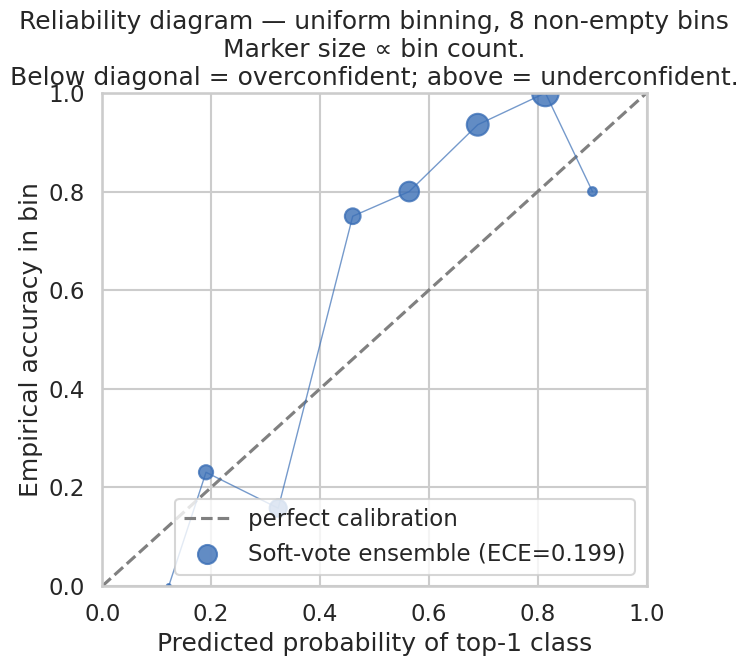

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Recompute correct / confidence from the ensemble's OOF predictions ---
P  = results['ensemble']['oof']
C  = results['ensemble']['classes']
pred  = C[np.argmax(P, axis=1)]
conf  = P.max(axis=1)
valid = (~df_tr['is_x'].to_numpy(bool)) & pd.Series(y_tr).notna().to_numpy(bool)
correct = (pred == np.asarray(y_tr)).astype(int)[valid]
conf_v  = conf[valid]

# --- Manual reliability binner (no degenerate quantile edges) ---
def manual_reliability(correct, conf, n_bins=8, mode='uniform'):
    correct = np.asarray(correct).astype(int)
    conf    = np.asarray(conf, dtype=float)
    if mode == 'uniform':
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        edges = np.unique(np.quantile(conf, np.linspace(0, 1, n_bins + 1)))
    edges = edges.copy(); edges[0] -= 1e-9; edges[-1] += 1e-9
    prob_bin, acc_bin, sizes = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (conf >= lo) & (conf < hi)
        if sel.sum() == 0: continue
        prob_bin.append(conf[sel].mean())
        acc_bin.append(correct[sel].mean())
        sizes.append(int(sel.sum()))
    return np.array(prob_bin), np.array(acc_bin), np.array(sizes)

prob_bin, acc_bin, sizes = manual_reliability(correct, conf_v, n_bins=8, mode='uniform')

print('bins (prob_pred, acc_emp, n):')
for p, a, n in zip(prob_bin.round(3), acc_bin.round(3), sizes):
    print(f'  prob={p:>5}  acc={a:>5}  n={n}')

ece = float(np.average(np.abs(prob_bin - acc_bin), weights=sizes))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect calibration')
ax.plot(prob_bin, acc_bin, color='#3b6fb6', alpha=0.7, lw=1)
ax.scatter(prob_bin, acc_bin, s=np.array(sizes)*8, color='#3b6fb6', alpha=0.8,
           label=f'Soft-vote ensemble (ECE={ece:.3f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Predicted probability of top-1 class')
ax.set_ylabel('Empirical accuracy in bin')
ax.set_title(f'Reliability diagram — uniform binning, {len(sizes)} non-empty bins\n'
             'Marker size ∝ bin count.\n'
             'Below diagonal = overconfident; above = underconfident.')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIGDIR/'reliability.png', dpi=120, bbox_inches='tight'); plt.show()

bins (prob_pred, acc_emp, n):
  prob=0.122  acc=  0.0  n=1
  prob=0.191  acc=0.231  n=13
  prob=0.323  acc=0.158  n=19
  prob= 0.46  acc= 0.75  n=16
  prob=0.564  acc=  0.8  n=25
  prob= 0.69  acc=0.935  n=31
  prob=0.814  acc=  1.0  n=46
  prob=0.901  acc=  0.8  n=5


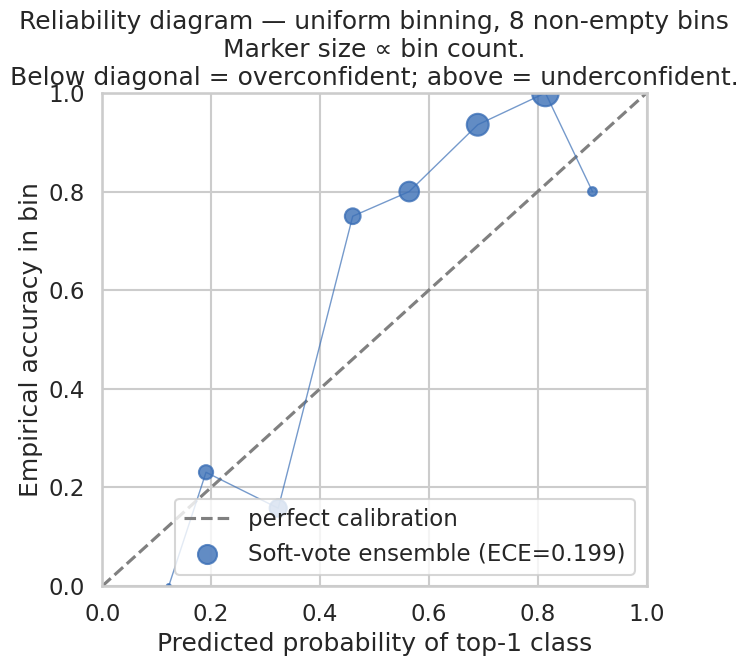

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Recompute correct / confidence from the ensemble's OOF predictions ---
P  = results['ensemble']['oof']
C  = results['ensemble']['classes']
pred  = C[np.argmax(P, axis=1)]
conf  = P.max(axis=1)
valid = (~df_tr['is_x'].to_numpy(bool)) & pd.Series(y_tr).notna().to_numpy(bool)
correct = (pred == np.asarray(y_tr)).astype(int)[valid]
conf_v  = conf[valid]

# --- Manual reliability binner (no degenerate quantile edges) ---
def manual_reliability(correct, conf, n_bins=8, mode='uniform'):
    correct = np.asarray(correct).astype(int)
    conf    = np.asarray(conf, dtype=float)
    if mode == 'uniform':
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    else:
        edges = np.unique(np.quantile(conf, np.linspace(0, 1, n_bins + 1)))
    edges = edges.copy(); edges[0] -= 1e-9; edges[-1] += 1e-9
    prob_bin, acc_bin, sizes = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (conf >= lo) & (conf < hi)
        if sel.sum() == 0: continue
        prob_bin.append(conf[sel].mean())
        acc_bin.append(correct[sel].mean())
        sizes.append(int(sel.sum()))
    return np.array(prob_bin), np.array(acc_bin), np.array(sizes)

prob_bin, acc_bin, sizes = manual_reliability(correct, conf_v, n_bins=8, mode='uniform')

print('bins (prob_pred, acc_emp, n):')
for p, a, n in zip(prob_bin.round(3), acc_bin.round(3), sizes):
    print(f'  prob={p:>5}  acc={a:>5}  n={n}')

ece = float(np.average(np.abs(prob_bin - acc_bin), weights=sizes))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect calibration')
ax.plot(prob_bin, acc_bin, color='#3b6fb6', alpha=0.7, lw=1)
ax.scatter(prob_bin, acc_bin, s=np.array(sizes)*8, color='#3b6fb6', alpha=0.8,
           label=f'Soft-vote ensemble (ECE={ece:.3f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Predicted probability of top-1 class')
ax.set_ylabel('Empirical accuracy in bin')
ax.set_title(f'Reliability diagram — uniform binning, {len(sizes)} non-empty bins\n'
             'Marker size ∝ bin count.\n'
             'Below diagonal = overconfident; above = underconfident.')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIGDIR/'reliability.png', dpi=120, bbox_inches='tight'); plt.show()

### 7.4 Confidence histogram + auto-accept threshold sweep

Two views of the same calibration question, stated in deployment terms.

- **Left** — distribution of top-1 confidence among rows the model got
  right vs. wrong. The further apart these distributions, the easier the
  threshold story.
- **Right** — for each candidate threshold τ on the X-axis: what fraction
  of rows would be auto-accepted (coverage), and what is their accuracy?
  Pick τ where accuracy meets the human baseline (~0.90), and read off
  coverage.


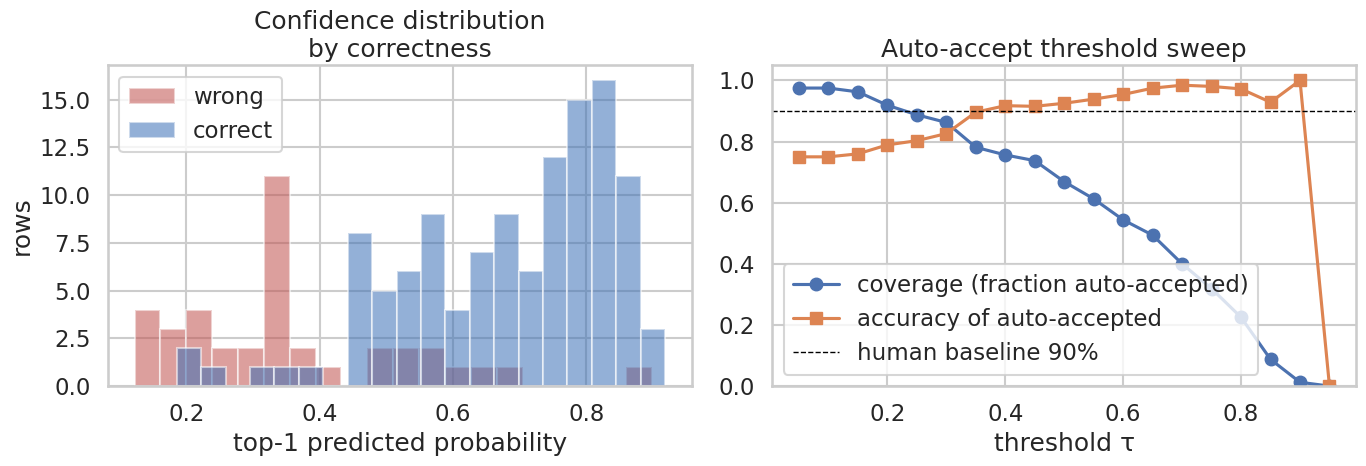

In [33]:
P_best  = results[best_alias]['oof']
C_best  = results[best_alias]['classes']
pred    = C_best[np.argmax(P_best, axis=1)]
conf    = P_best.max(axis=1)
valid   = (~df_tr['is_x'].to_numpy(bool)) & pd.Series(y_tr).notna().to_numpy(bool)
correct = (pred == np.asarray(y_tr)) & valid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(conf[valid & ~correct], bins=20, alpha=0.55, label='wrong',   color='#c0504d')
axes[0].hist(conf[valid &  correct], bins=20, alpha=0.55, label='correct', color='#3b6fb6')
axes[0].set_xlabel('top-1 predicted probability'); axes[0].set_ylabel('rows')
axes[0].set_title('Confidence distribution\nby correctness')
axes[0].legend()

taus = np.linspace(0.05, 0.95, 19); covs, accs = [], []
for t in taus:
    sel = valid & (conf >= t)
    covs.append(sel.mean())
    accs.append(((pred == np.asarray(y_tr)) & sel).sum() / max(sel.sum(), 1))
axes[1].plot(taus, covs, label='coverage (fraction auto-accepted)', marker='o')
axes[1].plot(taus, accs, label='accuracy of auto-accepted',         marker='s')
axes[1].axhline(0.90, ls='--', color='black', lw=1, label='human baseline 90%')
axes[1].set_xlabel('threshold τ')
axes[1].set_title('Auto-accept threshold sweep')
axes[1].set_ylim(0, 1.05); axes[1].legend()
plt.tight_layout(); plt.savefig(FIGDIR/'confidence_sweep.png', dpi=120, bbox_inches='tight'); plt.show()


### 7.5 Top character-n-grams per popular class

From the LR model's coefficient matrix: for each of the 10 most populous
classes, print the 8 character-n-grams whose presence pushes the model
most strongly *toward* that class. Useful both as an interpretability
exhibit and as a sanity check that the model has latched onto
occupation-specific Hebrew vocabulary.


In [34]:
lr_full = results['flat']['final']
vocab   = lr_full.tfidf.get_feature_names_out()
n_text  = len(vocab)
lr_clf  = lr_full.clf

vc_train = pd.Series(y_tr).value_counts().head(10)
for cls in vc_train.index:
    if cls not in lr_clf.classes_:
        continue
    ci = list(lr_clf.classes_).index(cls)
    coef = lr_clf.coef_[ci, :n_text]
    top = np.argsort(coef)[-8:][::-1]
    grams = [vocab[i] for i in top]
    print(f'class {cls} (n={vc_train[cls]:>3}):  ' + ', '.join(grams))


class 5223 (n= 11):  רת , מטיקה,  מו, ירת, מכירת, כירת , ירת , כירת
class 9112 (n=  9):  ון , ית , אירו, שק , דרני, אירוח, דרנית, ירוח
class 2512 (n=  8):  כנה, כנה , נה , תוכנה, תוכ,  תוכנ,  תו,  תוכ
class 5414 (n=  6):  ספר , ספר, בית , בית,  שמיר,  שומר,  שמי,  שומ
class 5120 (n=  6):  טבח , בח , טבח,  טב,  טבח ,  טבח, סעד, מסעד
class 2631 (n=  5):  אות , אות,  הל,  עס,  עסקי,  עסק, עסק, עסקי
class 5230 (n=  5):  פאית , ופאית, פאית, ופאי, קופא, פאי, ופא, קופאי
class 5412 (n=  5):   שוטר, שוטר, וטר,  שוט, שוט, שוטר , וטר , טר 
class 2511 (n=  5):  alyst, yst , yst, st , ta , aly, nal, nalys
class 5142 (n=  5):  טיקאי, טיקא, יקא, יקאי, יקאית, מטיקא, קאי, קאית


### 7.6 Post-fit hierarchy observation — `classification_report` by leading character

**This is the only place we acknowledge the codes have internal**
**structure, and we acknowledge it *as an output*, not an input.**

After fitting on 62 unstructured codes, we observe empirically that they
share leading characters. Aggregating predictions and labels by the
first character collapses the problem to ~8 readable groups — useful
as a drill-down even though the model never knew about the grouping.

The full report is saved to `artifacts/classification_report_leading_char.csv`.


In [35]:
from sklearn.metrics import classification_report

P_best = results[best_alias]['oof']
C_best = results[best_alias]['classes']
pred_best = C_best[np.argmax(P_best, axis=1)]
valid = (~df_tr['is_x'].to_numpy(bool)) & pd.Series(y_tr).notna().to_numpy(bool)

yt_d1 = pd.Series(np.asarray(y_tr)[valid]).astype(str).str[0]
yp_d1 = pd.Series(pred_best[valid]).astype(str).str[0]
ok = yt_d1.str.match(r'^\d$').fillna(False) & yp_d1.str.match(r'^\d$').fillna(False)

rep_dict = classification_report(yt_d1[ok], yp_d1[ok], digits=3,
                                  output_dict=True, zero_division=0)
rep_df   = pd.DataFrame(rep_dict).T.round(3)
rep_df.to_csv(ARTDIR/'classification_report_leading_char.csv')
display(rep_df)


,precision,recall,f1-score,support
1,0.000,0.000,0.000,4.000
2,0.878,0.915,0.896,47.000
3,0.800,0.800,0.800,15.000
4,0.667,0.571,0.615,7.000
5,1.000,0.959,0.979,49.000
7,0.846,1.000,0.917,11.000
8,0.833,0.833,0.833,6.000
9,0.889,0.941,0.914,17.000
accuracy,0.885,0.885,0.885,0.885
macro avg,0.739,0.753,0.744,156.000


### 7.7 X-coded recoverability

Of the rows the human coders flagged as `X` (could not classify), how
confidently can the model now propose the *full* code? Answers the
deployment question: "can the model help on the X-coded backlog?"


In [36]:
x_idx = np.where(df_tr['is_x'].to_numpy(dtype=bool))[0]
if len(x_idx) == 0:
    print('No X-coded rows landed in the train fold.')
else:
    P_best = results[best_alias]['oof']
    C_best = results[best_alias]['classes']
    rows_x = []
    for i in x_idx:
        p = P_best[i]
        if p.sum() == 0:
            continue
        order = np.argsort(-p)[:3]
        rows_x.append({
            'truth (X-coded)': df_tr.iloc[i]['SemelMishlachSofi'],
            'top1': C_best[order[0]], 'p1': round(float(p[order[0]]), 3),
            'top2': C_best[order[1]], 'p2': round(float(p[order[1]]), 3),
            'top3': C_best[order[2]], 'p3': round(float(p[order[2]]), 3),
        })
    print(pd.DataFrame(rows_x).to_string(index=False))


Empty DataFrame
Columns: []
Index: []


## 8. Save artefacts


In [37]:
import joblib
joblib.dump(results['flat'], ARTDIR/'flat_lr.joblib')
joblib.dump(results['lgb'],  ARTDIR/'lgb_flat.joblib')
joblib.dump(results['knn'],  ARTDIR/'knn_flat.joblib')
joblib.dump({k: results[k]['classes'] for k in ['ensemble']},
            ARTDIR/'ensemble_meta.joblib')
print('Artefacts at', ARTDIR.resolve())
print('Figures at', FIGDIR.resolve())

print('\nFinal CV results:'); display(df_results)
print('\nHeld-out test results:'); display(df_test_results)


Artefacts at /content/artifacts
Figures at /content/figures

Final CV results:


,top1,top3,macroF1,weightedF1,macroAUC_OvR,macroAP_OvR,kappa,kappa_q_int,brier,logloss,ECE
model,,,,,,,,,,,
Baseline (industry mode),0.719,NaN,NaN,NaN,NaN,NaN,0.710,0.835,NaN,NaN,NaN
LR flat,0.724,0.776,0.434,0.670,0.570,0.449,0.715,0.883,0.569,7.687,0.365
LightGBM flat,0.718,0.763,0.461,0.701,0.574,0.490,0.710,0.917,0.438,7.177,0.166
k-NN (k=5),0.699,0.769,0.382,0.632,0.749,0.438,0.689,0.871,0.493,8.223,0.071
Soft-vote ensemble,0.750,0.782,0.460,0.712,0.574,0.503,0.742,0.944,0.396,7.216,0.189



Held-out test results:


,top1,top3,macroF1,kappa,kappa_q_int
model,,,,,
Baseline,0.600,NaN,NaN,NaN,NaN
LR flat,0.771,0.857,0.591,0.761,0.899
LightGBM flat,0.857,0.886,0.751,0.850,0.834
k-NN,0.771,0.886,0.625,0.761,0.941
Soft-vote ensemble,0.857,0.886,0.751,0.850,0.834


## Deck mapping (≤10 slides)

| # | Slide | Asset from this notebook |
|---|---|---|
| 1 | Title | (text) |
| 2 | Business problem | (text) |
| 3 | Data overview | `figures/eda_missingness.png`, `figures/eda_target_hist.png` |
| 4 | Data structure | `figures/eda_pivot_industry_occupation.png` |
| 5 | Pipeline | flow diagram |
| 6 | Model comparison | `figures/eval_compare_metrics.png` |
| 7 | Results table | `artifacts/cv_results.csv`, `artifacts/test_results.csv` |
| 8 | Insights — confusion + leading-char drill-down | `figures/confusion_top15.png` + `artifacts/classification_report_leading_char.csv` |
| 9 | Deployment story — calibration + threshold | `figures/reliability.png` + `figures/confidence_sweep.png` |
| 10| Limitations & roadmap | (text) |
